In [40]:
# 0 Importaciones
# 0.1 Importar librerias
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) # Para ver todas las columnas

In [41]:
# 0.2. Importamos el dataframe para el analisis
df = pd.read_csv('../Data/cleaned/df_cleaned.csv')


In [42]:
# Cuando cambiamos el tipo de datos a datetime, category y pasamos el df a un archivo excel, estos tipos de datos no los comprende excel
# Al recogerlos en otro archivo ipynb, se pierden en un nuevo df y tenemos que reconvertir los tipos de datos

# Cambiar el tipo de datos a categoria de nuevo
cols_cat = [
    'job', 'marital', 'education',
    'default', 'housing', 'loan',
    'contact', 'poutcome'
]

df[cols_cat] = df[cols_cat].astype('category')

# Cambiar el tipo de datos de fecha de str a datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   age                43000 non-null  int64         
 1   job                43000 non-null  category      
 2   marital            43000 non-null  category      
 3   education          43000 non-null  category      
 4   default            43000 non-null  category      
 5   housing            43000 non-null  category      
 6   loan               43000 non-null  category      
 7   contact            43000 non-null  category      
 8   duration           43000 non-null  int64         
 9   campaign           43000 non-null  int64         
 10  poutcome           43000 non-null  category      
 11  emp.var.rate       43000 non-null  float64       
 12  cons.price.idx     43000 non-null  float64       
 13  cons.conf.idx      43000 non-null  float64       
 14  euribor3m        

In [43]:
# ANÁLISIS
# El objetivo de este análisis es identificar qué tipo de clientes tienen mayor probabilidad de suscripción al producto (variable objetivo: y),
# con el fin de ayudar al equipo de marketing a enfocar sus campañas en los segmentos más rentables.
# Por este motivo, no se analizarán todas las variables de forma exhaustiva, sino aquellas que potencialmente puedan influir en la decisión del cliente.
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   age                43000 non-null  int64         
 1   job                43000 non-null  category      
 2   marital            43000 non-null  category      
 3   education          43000 non-null  category      
 4   default            43000 non-null  category      
 5   housing            43000 non-null  category      
 6   loan               43000 non-null  category      
 7   contact            43000 non-null  category      
 8   duration           43000 non-null  int64         
 9   campaign           43000 non-null  int64         
 10  poutcome           43000 non-null  category      
 11  emp.var.rate       43000 non-null  float64       
 12  cons.price.idx     43000 non-null  float64       
 13  cons.conf.idx      43000 non-null  float64       
 14  euribor3m        

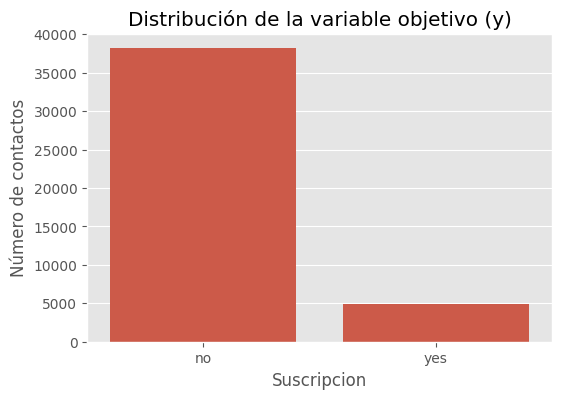

In [ ]:
# 0. Distribucion de variable objetivo 'y'
df['y'].value_counts(dropna=False)

counts = df['y'].value_counts(dropna=False)
plt.figure(figsize=(6,4))
sns.barplot(
    x=counts.index,
    y=counts.values
)

plt.title("Distribución de la variable objetivo (y)")
plt.xlabel("Suscripcion")
plt.ylabel("Número de contactos")

plt.show()

# Conclusiones: La mayoría de clientes no suscriben el producto, lo que indica un claro desbalance en la variable objetivo.

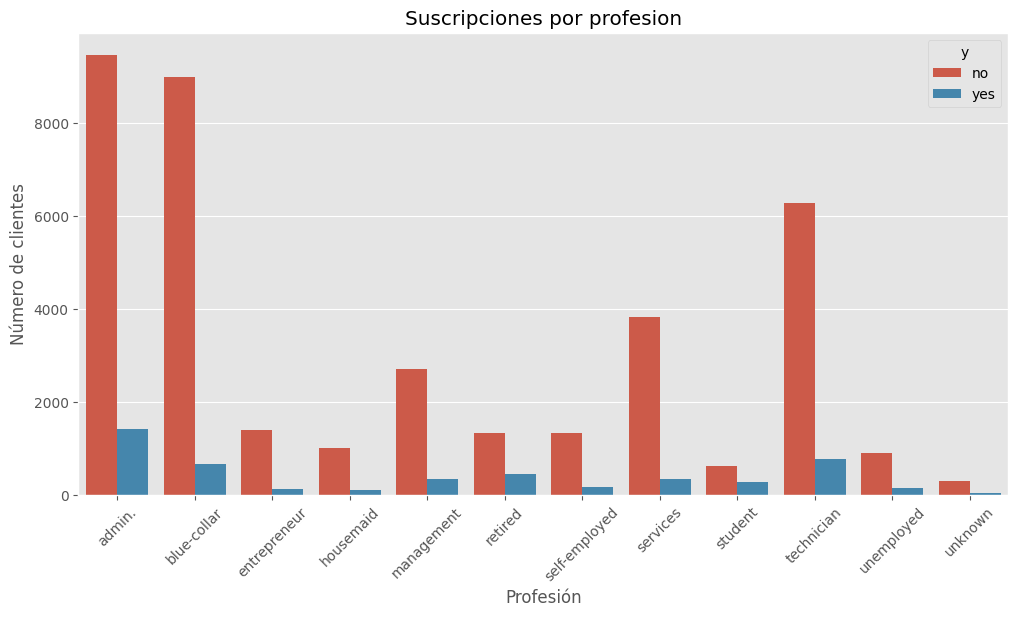

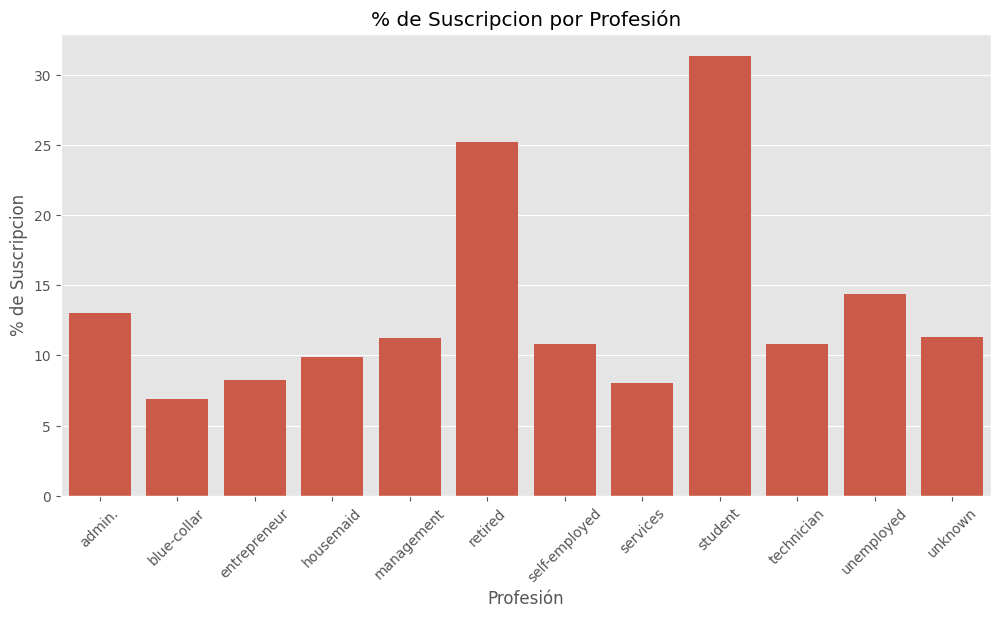

In [45]:
# 1. Perfil del cliente
# 1.1.1 Job (analisis de valores absolutos)

plt.figure(figsize=(12,6))

sns.countplot(data = df, x = 'job', hue = 'y') # Countplot es un grafico de barra que cuenta valores
plt.title('Suscripciones por profesion')
plt.xlabel('Profesión')
plt.ylabel('Número de clientes')
plt.xticks(rotation = 45)
plt.show()


# 1.1.2 Job, queremos ver que profesiones mas se suscriben, no en valores absolutos si no la probabilidad sobre el total
job_y = pd.pivot_table(
    df,
    index="job",
    columns="y",
    aggfunc="size"
)
job_y['% yes sobre total'] = round(job_y['yes'] / (job_y['no'] + job_y['yes']) * 100, 2)
job_y

# Grafico
plt.figure(figsize=(12,6))
sns.barplot(x=job_y.index, y = job_y['% yes sobre total'])

plt.title('% de Suscripcion por Profesión')
plt.ylabel('% de Suscripcion')
plt.xlabel('Profesión')
plt.xticks(rotation =45)
plt.show()


# Conclusiones: Los trabajos que mas se suscriben son admin y technician, para estrategias de impacto por alto volumen
# Por tanto es mas importante para el volumen y gran parte del negocio


# Conclusiones: El grupo 'student' es el que tiene mayor eficiencia de conversion para suscripcion junto a 'retired'
# Es importante para estrategia, es muy eficiente pero pequeño




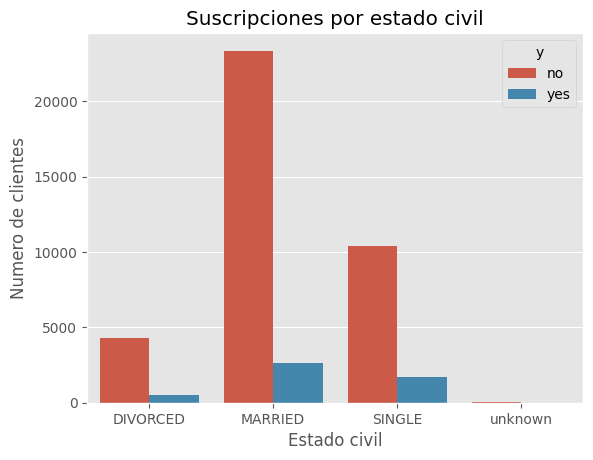

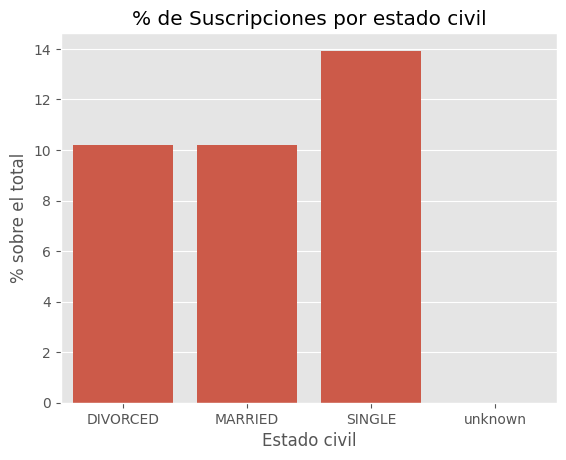

In [46]:
# 1.2 Marital 
# 1.2.1 (valores absolutos)

sns.countplot(data = df, x = 'marital', hue = 'y')
plt.title('Suscripciones por estado civil')
plt.xlabel('Estado civil')
plt.ylabel('Numero de clientes')
plt.show()



# 1.2.2 (Eficiencia del segmento)
marital_y = pd.pivot_table(
    data = df,
    index= 'marital',
    columns= 'y',
    aggfunc= 'size'
)
marital_y_filtrado = marital_y.drop(index="unknown") # Unknown no nos interesa para este grafico, ya que en el de valores absolutos es infimo y daria resultados poco concluyentes

marital_y_filtrado['% yes sobre total'] = round((marital_y_filtrado['yes'] / (marital_y_filtrado['no'] + marital_y_filtrado['yes']) * 100),2)

sns.barplot(x = marital_y_filtrado.index, y = marital_y_filtrado['% yes sobre total'])
plt.title('% de Suscripciones por estado civil')
plt.xlabel('Estado civil')
plt.ylabel('% sobre el total')
plt.show()


# Conclusiones: El mayor volumen de clientes lo tenemos en la categoria de 'married'
# Conclusiones: El Estado civil que mejor conversion tiene en suscripciones es el single



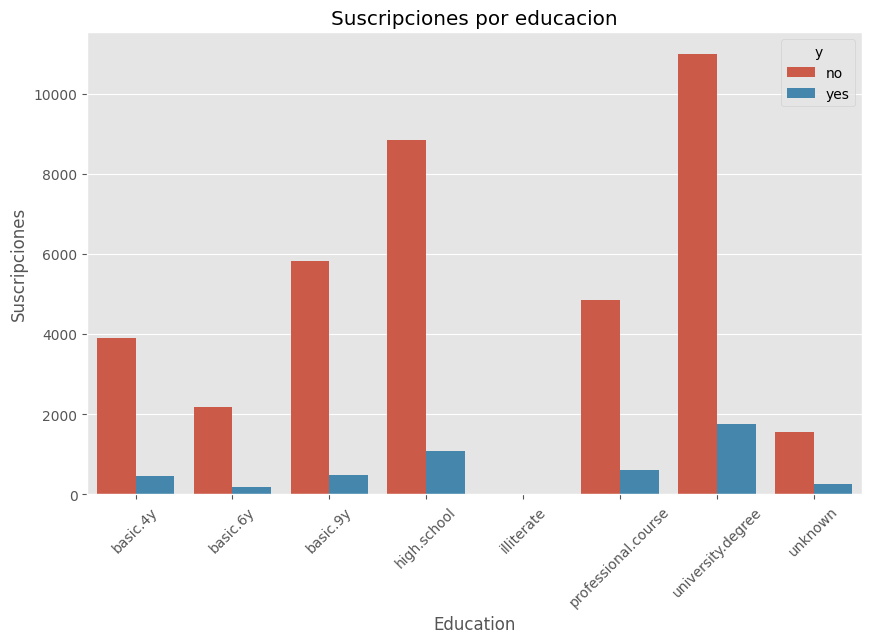

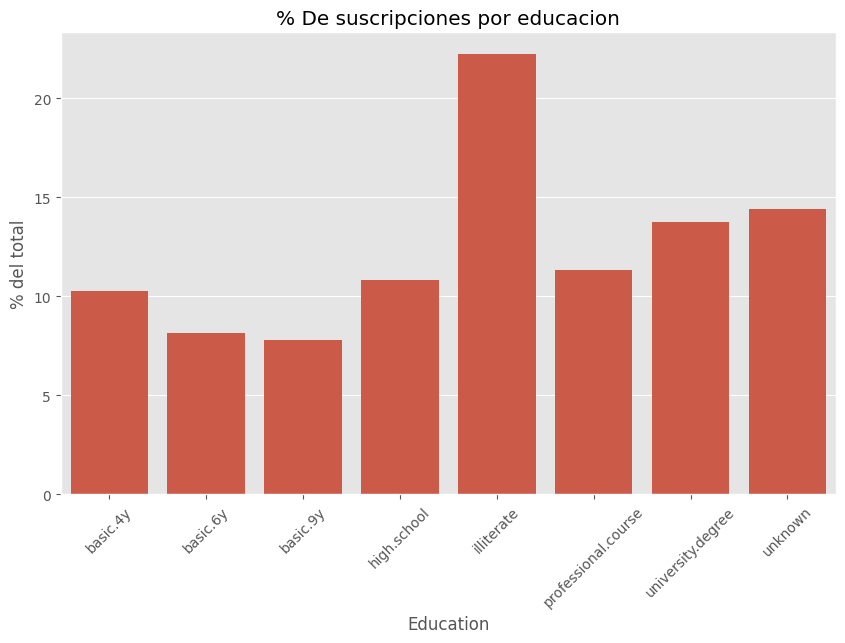

In [47]:
# 1.3 Education
# 1.3.1 Valores absolutos

plt.figure(figsize=(10,6))
sns.countplot(data = df, x = 'education', hue = 'y')
plt.title('Suscripciones por educacion')
plt.xticks(rotation = 45)
plt.xlabel('Education')
plt.ylabel('Suscripciones')
plt.show()

# Conclusiones: En valores absolutos, tenemos mas suscripciones a produtos en personas que tienen 'high.school' y en 'university.degree'

# 1.3.2 Eficiencia del segmento
education_y = pd.pivot_table(
    data = df,
    index = 'education',
    columns= 'y',
    aggfunc= 'size'
)

education_y['% sobre el total'] = round((education_y['yes'] / (education_y['no'] + education_y['yes'])* 100),2)
plt.figure(figsize=(10,6))
sns.barplot(data = education_y, x = education_y.index, y = '% sobre el total')
plt.title('% De suscripciones por educacion')
plt.xticks(rotation = 45)
plt.xlabel('Education')
plt.ylabel('% del total')
plt.show()


# Conclusiones: En valores absolutos, tenemos mas suscripciones a produtos en personas que tienen 'high.school' y en 'university.degree'

# Conclusiones: 'illirate', no lo tendremos en cuenta porque la muestra es ínfima, son bastante eficientes: 'university.degree', 'professional.course' y 'high.school'
# 'unknown' la muestra es pequeña pero tiene buena eficiencia, seria una buena idea llamar a los clientes para aclarar su educacion y mejorar la muestra


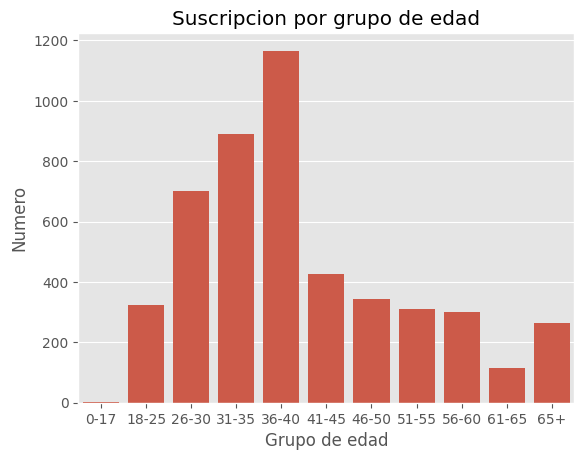

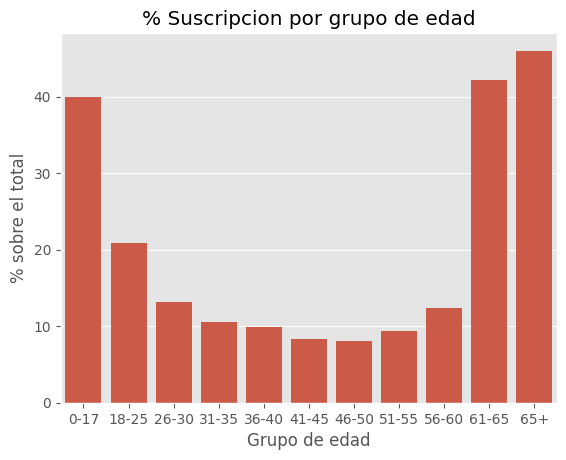

In [48]:
# 1.4 Age
# 1.4.1 Valores absolutos (Que edad se suscribe mas a un producto)
df['age'].value_counts()

age_y = df[['age','y']][df['y'] == 'yes'] # Solo queremos los que se suscriben 'df['y'] == 'yes' '
age_y.sort_values('age', ascending=True, inplace= True)

# Crear grupos de edad
bins = [0,17,25,30,35,40,45,50,55,60,65,100]

labels = ['0-17','18-25','26-30','31-35','36-40',
          '41-45','46-50','51-55','56-60','61-65','65+']

age_y["grupo_edad"] = pd.cut(age_y["age"],
                          bins=bins,
                          labels=labels)


# Creamos un grafico de barras para ver que grupo es el que mas se suscribe
sns.countplot(data = age_y, x = 'grupo_edad')
plt.title('Suscripcion por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Numero')
plt.show()

# Conclusiones: Podemos ver que el grupo de edad que mas se suscribe es el 36-45 años y el que menos '0-17' y '61-65'

# 1.4.2 Grupo mas eficiente
age_y2 = df[['age', 'y']].copy()
age_y2["grupo_edad"] = pd.cut(age_y2["age"],
                          bins=bins,
                          labels=labels)

age_y2_pivot = pd.pivot_table(
    data = age_y2,
    columns= 'y',
    index= 'grupo_edad',
    aggfunc = 'size'
)

age_y2_pivot['% sobre el total'] = round((age_y2_pivot['yes'] / (age_y2_pivot['no'] + age_y2_pivot['yes']) * 100), 2)
sns.barplot(data= age_y2_pivot, x='grupo_edad', y = '% sobre el total')
plt.title('% Suscripcion por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('% sobre el total')
plt.show()

# Conclusiones: los grupos de 61-65 años y + 65 son los que tienen mejor tasa de conversión

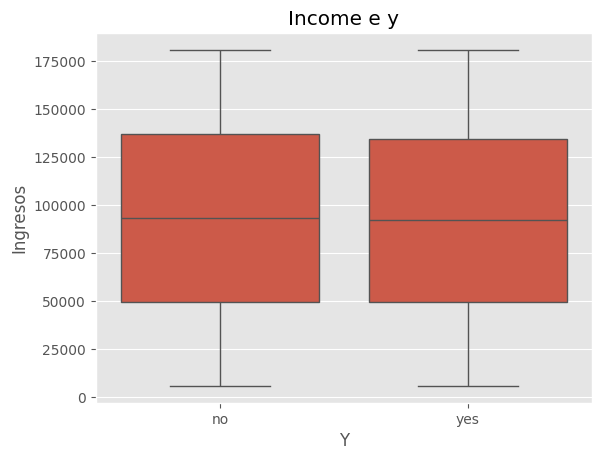

,mean,median
y,,
no,93324.595031,93206.5
yes,92584.301197,92144.5


In [49]:
# 1.5 Income
# Ver mediana, dispersion y posibles outliers
sns.boxplot(data=df,x="y",y="Income")
plt.title('Income e y')
plt.xlabel('Y')
plt.ylabel('Ingresos')
plt.show()

df.groupby("y")["Income"].agg(["mean", "median"])

# Conclusiones: No se observa diferencias significativas en la suscripcion de clientes a los productos segun los ingresos

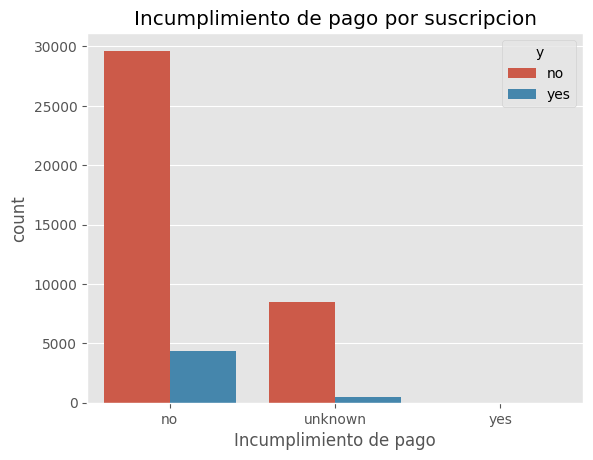

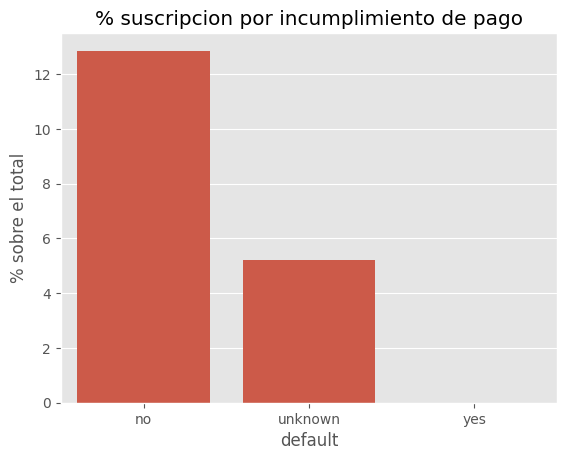

In [50]:
# 2 Incumplimientos financieros y préstamos
# 2.1 Default (incumplimiento financiero)
# 2.1.1 Valores absolutos

sns.countplot(data = df, x = 'default', hue = 'y')
plt.title('Incumplimiento de pago por suscripcion')
plt.xlabel('Incumplimiento de pago')
plt.show()

# 2.1.2 Eficiencia del segmento
default_y = pd.pivot_table(
    data = df,
    index = 'default',
    columns = 'y',
    aggfunc='size',
    fill_value= 0 # Para rellenar valores nan por 0
)

default_y['% sobre el total'] = round((default_y['yes'] / (default_y['yes'] + default_y['no'])* 100),2)
sns.barplot(data = default_y, x = default_y.index, y = '% sobre el total')
plt.title('% suscripcion por incumplimiento de pago')
plt.show()

# Conclusiones: El 12 % de las personas que no incumplen pagos tienen suscripcion a alguno de nuestros productos,
#  aparentemente no tenemos clientes que incumplan pagos que tengan servicios con nosotros, pero si tenemos muchos clientes de los que no sabemos
#  su historial de incumplimiento de pagos, seria bueno llamar y completar la informacion
# Casi 8000 personas que son 'unknown'

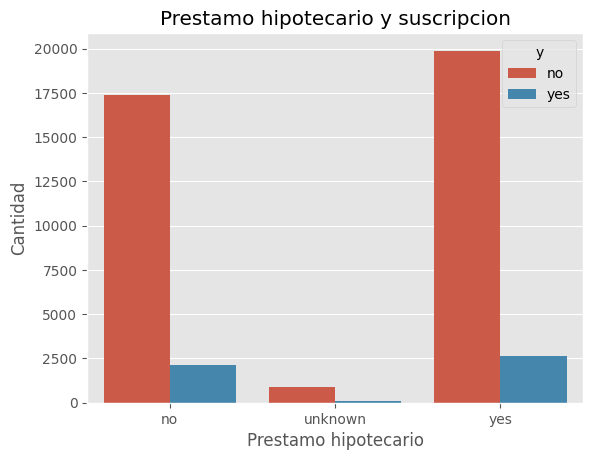

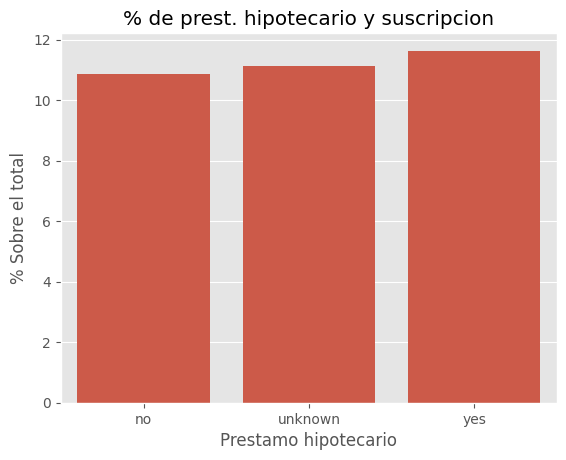

In [51]:
# 2.2 Housing (Si tiene prestamo hipotecario)
# 2.2.1 Valores absolutos

sns.countplot(data = df, x = 'housing', hue = 'y')
plt.title('Prestamo hipotecario y suscripcion')
plt.xlabel('Prestamo hipotecario')
plt.ylabel('Cantidad')
plt.show()

# 2.2.2  Eficiencia del segmento
housing_y = pd.pivot_table(
    data = df, 
    index = 'housing',
    columns = 'y',
    aggfunc = 'size'
)
housing_y['% sobre el total'] = round((housing_y['yes'] / (housing_y['yes'] + housing_y['no']) * 100),2)
sns.barplot(data = housing_y, x = housing_y.index, y = '% sobre el total')
plt.title('% de prest. hipotecario y suscripcion')
plt.xlabel('Prestamo hipotecario')
plt.ylabel('% Sobre el total')
plt.show()

# Conclusiones: Números muy similares, tanto los que tienen prestamo hipotecario como los que no



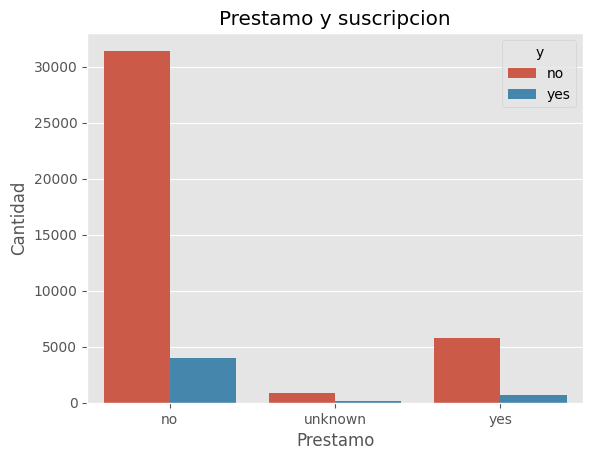

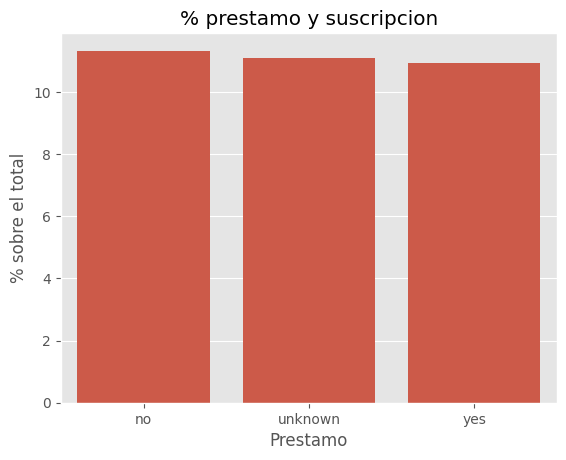

In [52]:
# 2.3 Loan (Si tiene algun prestamo)
# 2.3.1 Valores absolutos

sns.countplot(data = df, x = 'loan', hue = 'y')
plt.title('Prestamo y suscripcion')
plt.xlabel('Prestamo')
plt.ylabel('Cantidad')
plt.show()

# 2.3.2  Eficiencia del segmento
loan_y = pd.pivot_table(
    data = df, 
    index = 'loan',
    columns= 'y',
    aggfunc= 'size'
)
loan_y['% sobre el total'] = round((loan_y['yes'] / (loan_y['yes'] + loan_y['no']) * 100),2)
sns.barplot(data = loan_y, x = loan_y.index, y = '% sobre el total')
plt.title('% prestamo y suscripcion')
plt.xlabel('Prestamo')
plt.ylabel('% sobre el total')
plt.show()

# Conclusiones: Podemos apreciar que los que mas se suscriben son los que no tienen prestamos en valores absolutos, pero a nivel de eficiencia. Ambos tienen 
# buena tasa de conversion

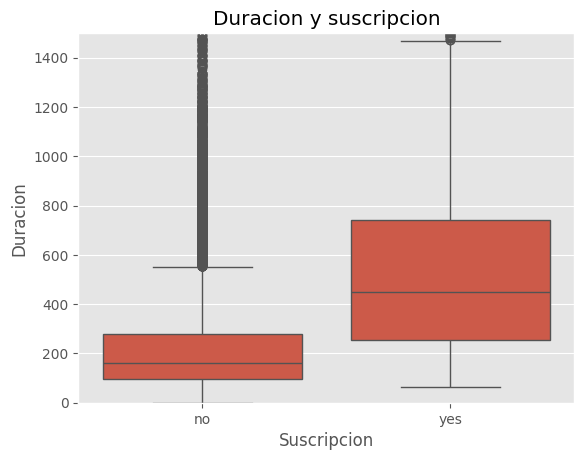

In [53]:
# 3 Comportamiento del cliente
# 3.1 Duration

df['duration'].sample(10)

sns.boxplot(data = df, x = 'y', y = 'duration')
plt.title('Duracion y suscripcion')
plt.xlabel('Suscripcion')
plt.ylabel('Duracion')
plt.ylim(0, 1500) # Para no deformar el gráfico
plt.show()

# Conclusion: la mediana para suscripción está por encima de 400s y la de no suscripcion por debajo de 200
# Esto sugiere una relación positiva entre la duración de la llamada y la probabilidad de suscripción.

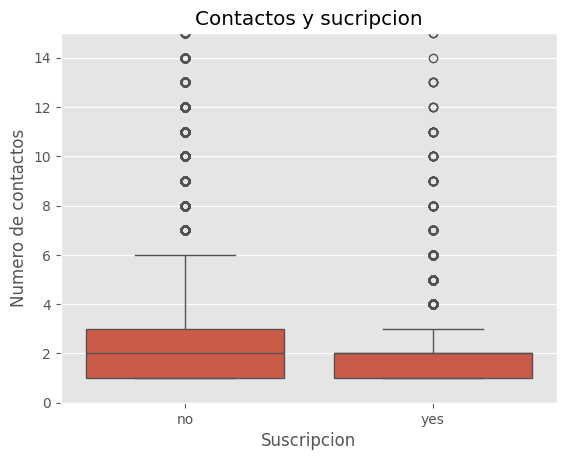

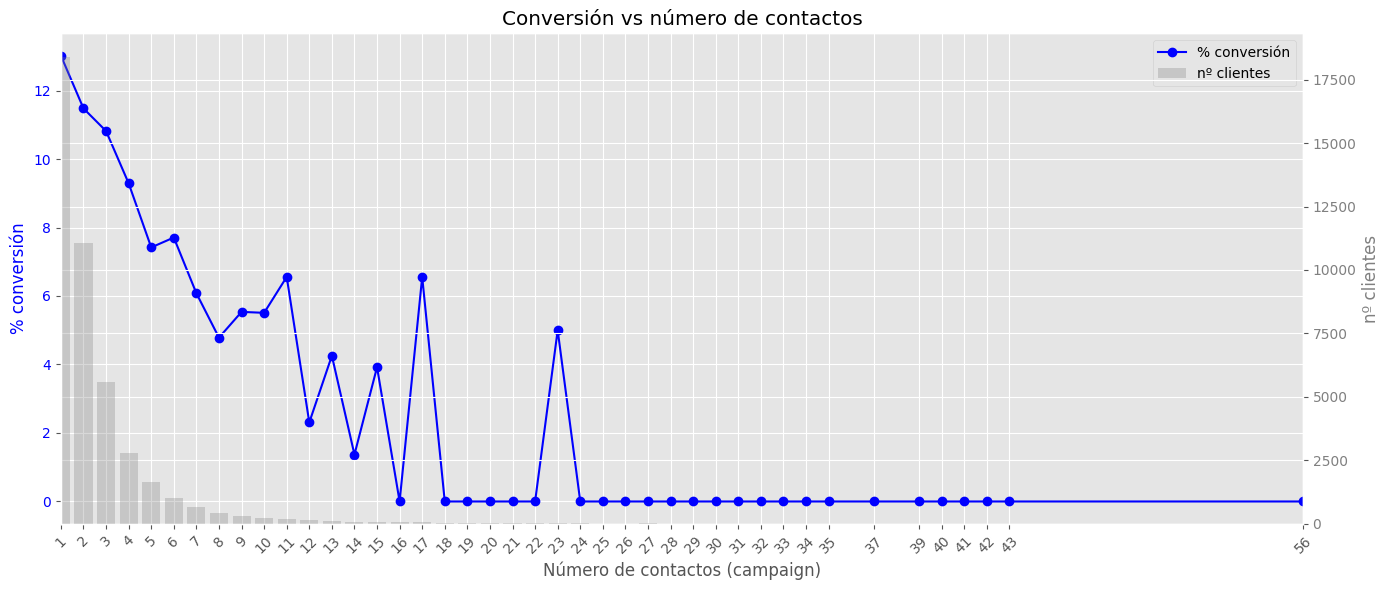

In [54]:
# 3.2 Campaign (El número de contactos realizados durante esta campaña para este cliente.)

# 3.2.1 Boxplot
sns.boxplot(data=df, x='y', y='campaign')
plt.title('Contactos y sucripcion')
plt.xlabel('Suscripcion')
plt.ylabel('Numero de contactos')
plt.ylim(0,15)

df.groupby('y')['campaign'].describe() # Ambos tienen la misma mediana en 2

# Conclusion: Los clientes suscritos tienden a requerir pocos contactos, la distribución está concentrada en valores bajos.
# Esto podria sugerir que insistir demasiado tienen menor conversion y que los clientes más receptivos aceptan antes


# 3.2.2 Grafico compuesto
conversion = df.groupby('campaign')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
)

counts = df['campaign'].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(14,6))

# Línea de conversión (eje X numérico)
ax1.plot(conversion.index, conversion.values,
         marker='o', color='blue', label='% conversión')

ax1.set_xlabel('Número de contactos (campaign)')
ax1.set_ylabel('% conversión', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Forzar eje X como valores reales
ax1.set_xticks(conversion.index)
ax1.set_xlim(conversion.index.min(), conversion.index.max())
ax1.set_xticklabels(conversion.index, rotation=45)

# Volumen
ax2 = ax1.twinx()
ax2.bar(counts.index, counts.values,
        alpha=0.3, color='gray', label='nº clientes')

ax2.set_ylabel('nº clientes', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Leyenda
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Conversión vs número de contactos')
plt.tight_layout()
plt.show()

# Conclusion: La conversión decrece conforme aumenta el número de contactos, y el volumen se concentra en los primeros intentos, por lo que contactar mas veces no es mas eficiente

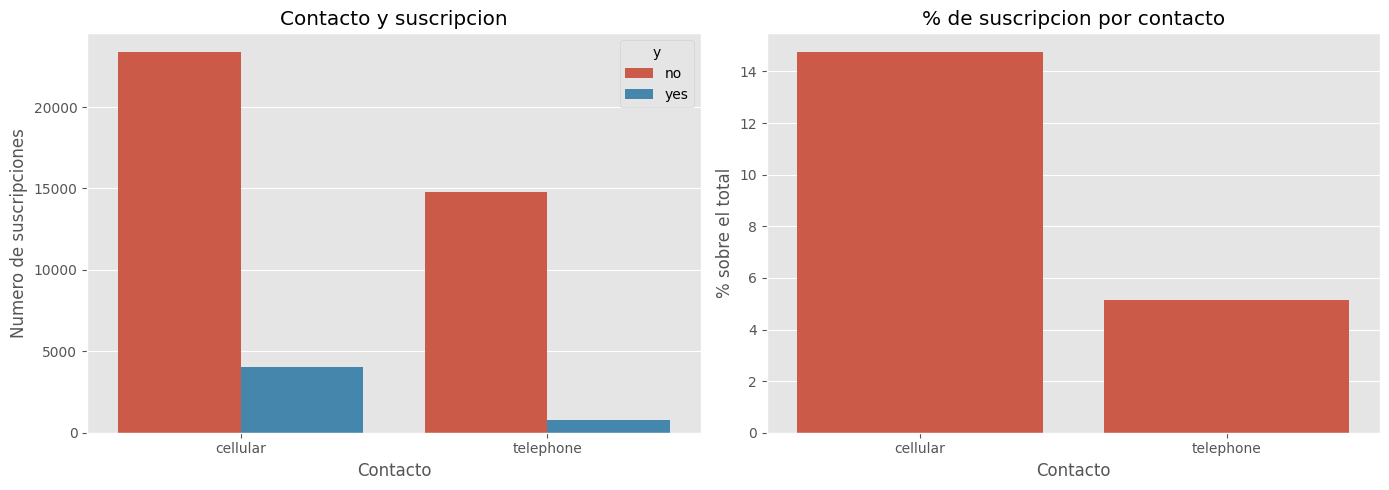

In [55]:
# 3.3 Contact (metodo de contacto usado para contactar el cliente)

df[['contact','y']].value_counts(dropna=False)
contact_y = pd.crosstab(df['contact'], df['y'])

# 3.3.1 Gráfico de barras (valores absolutos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14,5))
sns.countplot(data = df, x = 'contact', hue = 'y', ax = ax1)
ax1.set_title('Contacto y suscripcion')
ax1.set_ylabel('Numero de suscripciones')
ax1.set_xlabel('Contacto')


# 3.3.2 Gráfico % sobre el total

contact_y['% sobre el total'] = round(contact_y['yes'] / (contact_y['no'] + contact_y['yes']) * 100, 2) # Yes cuanto representa respecto al total

# En lugar de calcularlo manualmente lo podemos hacer:
#contact_y = pd.crosstab(df['contact'], df['y'], normalize='index') * 100

sns.barplot(data = contact_y, x = contact_y.index, y = '% sobre el total', ax = ax2)
ax2.set_title('% de suscripcion por contacto')
ax2.set_xlabel('Contacto')
ax2.set_ylabel('% sobre el total')
plt.tight_layout()
plt.show()

# Conclusiones: En valores absolutos tenemos mas suscripciones cuando contactamos a través de 'cellular' y además es el campo con mayor conversion, es decir el mas eficiente

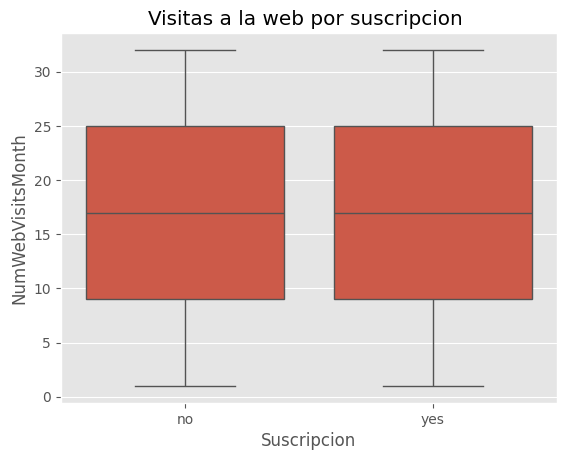

In [56]:
# 3.4 NumWebVisitsMonth (numero de visitas a la web al mes)

NumVisitas_agrupados = df.groupby('y')['NumWebVisitsMonth'].agg(['mean', 'median', 'count']).reset_index()
NumVisitas_agrupados

sns.boxplot(data=df, x='y', y='NumWebVisitsMonth')
plt.title('Visitas a la web por suscripcion ')
plt.xlabel('Suscripcion')
plt.ylabel('NumWebVisitsMonth')
plt.show()

# Conclusion: La variable NumWebVisitsMonth no muestra diferencias relevantes entre clientes que se suscriben y los que no.


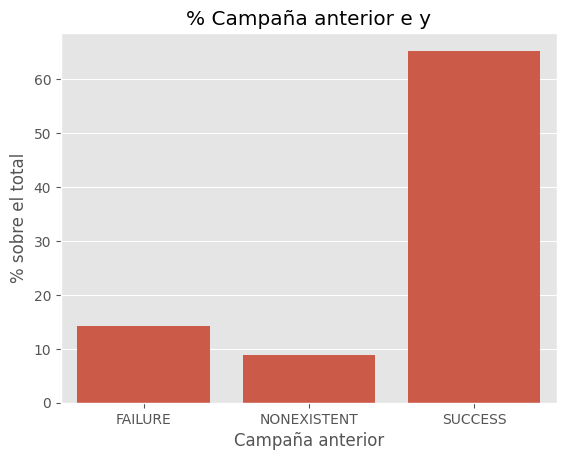

In [57]:
# 3.5 poutcome (Resultado de la campaña de marketing anterior)
df['poutcome'].value_counts()

poutcome_y = pd.crosstab(df['poutcome'], df['y'], normalize= "index") * 100
poutcome_y

sns.barplot(data = poutcome_y, x = poutcome_y.index, y = 'yes')
plt.title('% Campaña anterior e y')
plt.xlabel('Campaña anterior')
plt.ylabel('% sobre el total')
plt.show()

# Conclusión:
# La variable 'poutcome' parece tener una fuerte relación con la suscripción del producto.
# Los clientes cuya campaña anterior fue exitosa presentan una tasa de conversión del 65.3%,
# muy superior a la observada en clientes sin historial previo (8.8%) o con campañas fallidas (14.2%).
# Esto sugiere que el resultado de campañas anteriores es un factor relevante para explicar la variable objetivo 'y'.




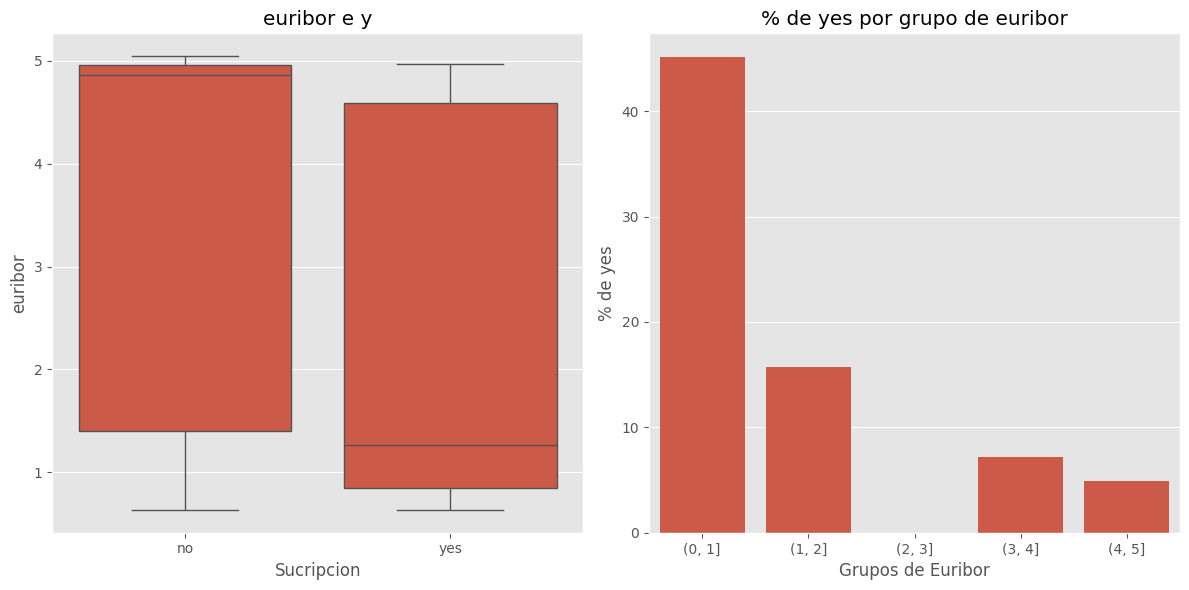

In [58]:
# 4. Economia
# 4.1 euribor3m

df.groupby("y")["euribor3m"].agg(["mean", "median"])

# Nota: Los clientes que se suscriben (yes) están asociados a valores de Euribor mucho más bajos. Cuando el Euribor es bajo, la probabilidad de suscripción aumenta.

# Creamos los contenedores
bins = [0, 1, 2, 3, 4, 5]


df["euribor_grupo"] = pd.cut(
    df["euribor3m"],
    bins=bins
)

df["euribor_grupo"].value_counts().sort_index()

euribor_y = pd.crosstab(
    df["euribor_grupo"],
    df["y"],
    normalize="index",
) * 100

# Graficos
# Figura con 2 ejes
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,6))

# 1º grafico boxplot
sns.boxplot(data = df, x = 'y', y ='euribor3m', ax = ax1)
ax1.set_title('euribor e y')
ax1.set_xlabel('Sucripcion')
ax1.set_ylabel('euribor')


# 2º # % de yes por grupo de euribor
sns.barplot(data = euribor_y, x = euribor_y.index, y = 'yes', ax = ax2)
ax2.set_title('% de yes por grupo de euribor')
ax2.set_xlabel('Grupos de Euribor')
ax2.set_ylabel('% de yes')

plt.tight_layout()
plt.show()

# Conclusiones: A medida que aumenta el 'euribor3m', la tasa de suscripcion 'y' disminuye de forma significativa, pasando del 45% en niveles bajos al menos del 5% en niveles altos


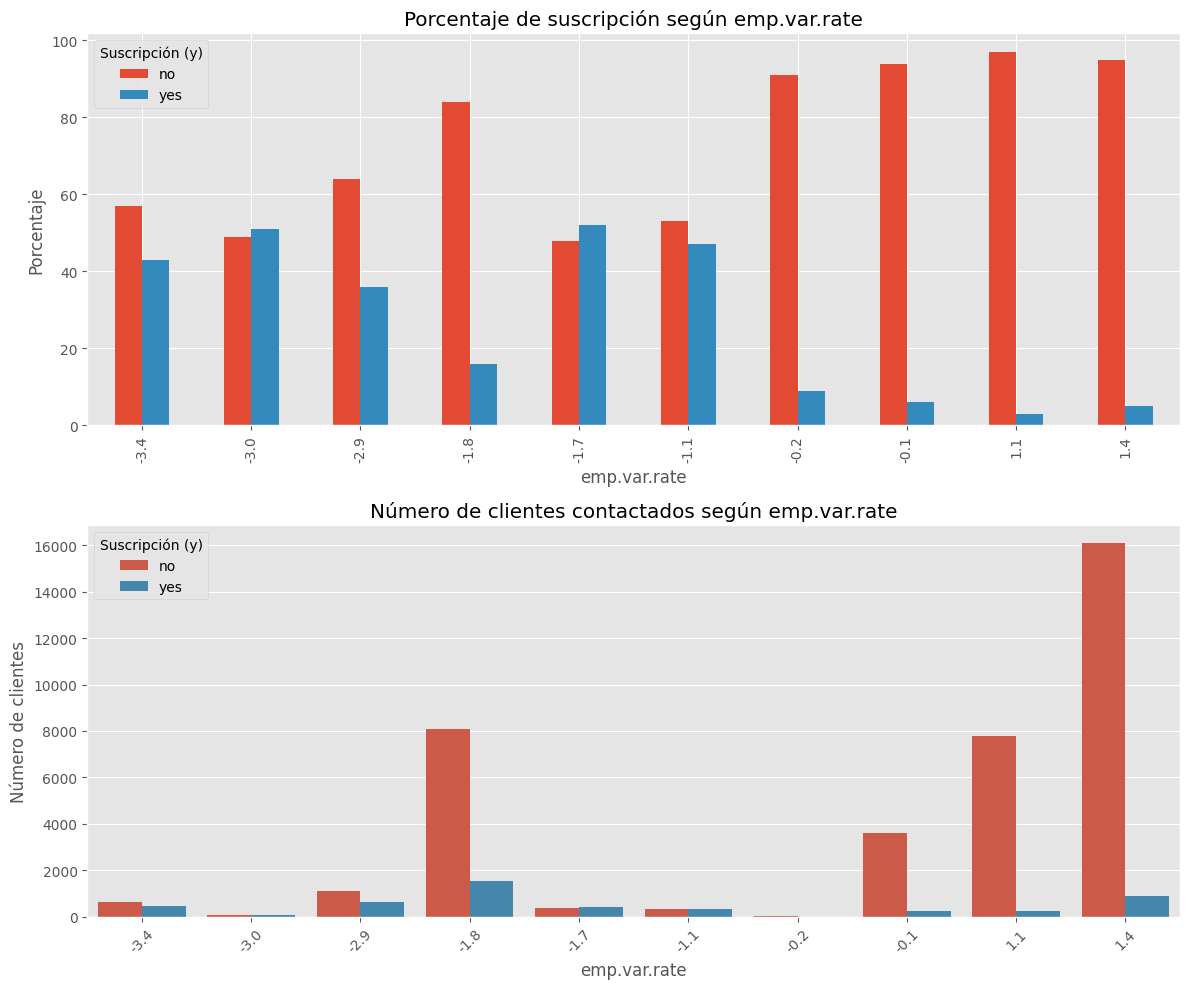

In [59]:
# 4.2 emp.var.rate: La tasa de variación del empleo.

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1º Gráfico: porcentaje por emp.var.rate y y
tabla = pd.crosstab(
    df['emp.var.rate'],
    df['y'],
    normalize='index'
).round(2) * 100

tabla.plot(kind='bar', ax=axes[0])

axes[0].set_title('Porcentaje de suscripción según emp.var.rate')
axes[0].set_xlabel('emp.var.rate')
axes[0].set_ylabel('Porcentaje')
axes[0].legend(title='Suscripción (y)')

# 2º Gráfico: conteo de clientes
sns.countplot(
    x='emp.var.rate',
    hue='y',
    data=df,
    ax=axes[1]
)

axes[1].set_title('Número de clientes contactados según emp.var.rate')
axes[1].set_xlabel('emp.var.rate')
axes[1].set_ylabel('Número de clientes')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Suscripción (y)')

plt.tight_layout()
plt.show()

# Conclusiones: Tenemos mas clientes contactados cuando al valor es positivo, sin embargo cuando los numeros son negativos tenemos mucho mejor tasa de conversion.
# Ejemplo cuanto emp.var.rate es 1.4, nuestro % de yes para 'y' es 5%, sin embargo para -1,8 es del 16%
# Esto nos sugiere que en periodos de menor confianza económica los clientes se suscriben más a los productos ofrecidos.

Mediana para yes: 93.2
 Mediana para no: 93.918
 Valor Maximo : 94.767
 Valor Minimo : 92.201



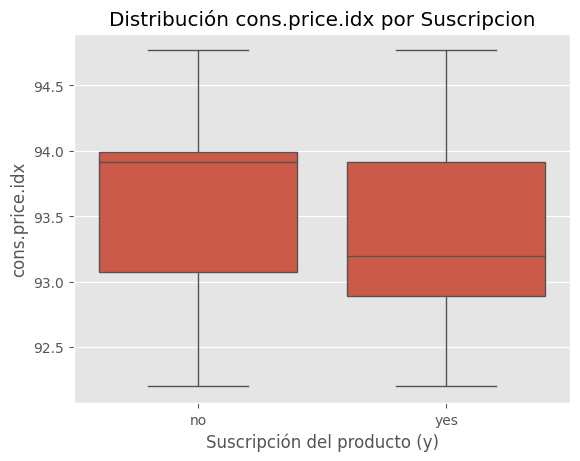

In [60]:
# 4.3 cons.price.idx: El índice de precios al consumidor

df['cons.price.idx'].value_counts()

# Mediana de cons.price.idx para cada clase de y
medianas = df.groupby('y')['cons.price.idx'].median()
print(f"Mediana para yes: {medianas['yes']}\n", # Mediana para yes: 93.2
      f"Mediana para no: {medianas['no']}\n", #  Mediana para no: 93.918
      f"Valor Maximo : {df['cons.price.idx'].max()}\n", #  Valor Maximo : 94.767
      f"Valor Minimo : {df['cons.price.idx'].min()}\n") #  Valor Minimo : 92.201

# Grafico: boxplot
sns.boxplot(data=df, x='y', y='cons.price.idx')

plt.title('Distribución cons.price.idx por Suscripcion')
plt.xlabel('Suscripción del producto (y)')
plt.show()

# Conclusiones: Aunque la diferencia entre medianas (93.2 vs 93.918) pueda parecer moderada,
#  el análisis debe interpretarse dentro del rango limitado (92.201 a 94.767),
#  lo que indica que pequeñas variaciones en cons.price.idx pueden estar asociadas a cambios en la probabilidad de suscripción.

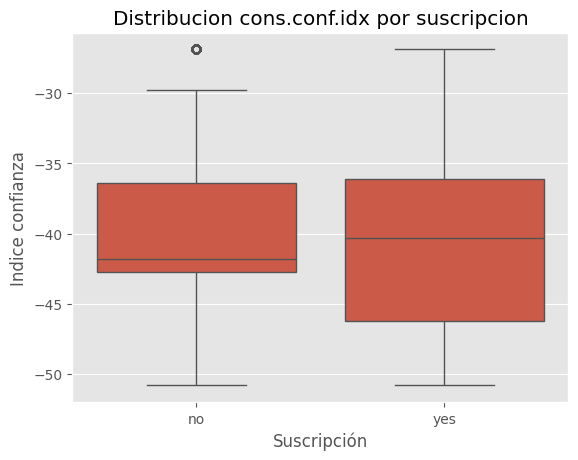

In [61]:
# 4.4 cons.conf.idx (El índice de confianza del consumidor)



# Grafico: boxplot
sns.boxplot(data = df, x='y', y = 'cons.conf.idx')
plt.title('Distribucion cons.conf.idx por suscripcion')
plt.xlabel('Suscripción')
plt.ylabel('Indice confianza')
plt.show()



# En la variable cons.conf.idx se observa una diferencia en la dispersión entre ambos grupos. 
# Los clientes que no suscriben presentan una distribución más concentrada, con un IQR más reducido y una mediana cercana al primer cuartil.
# En cambio, los clientes que sí suscriben muestran una distribución más amplia, con un rango intercuartílico mayor y una mediana más centrada dentro del mismo.
#  Esto sugiere que la suscripción del producto ocurre en un rango más diverso de niveles de confianza del consumidor.


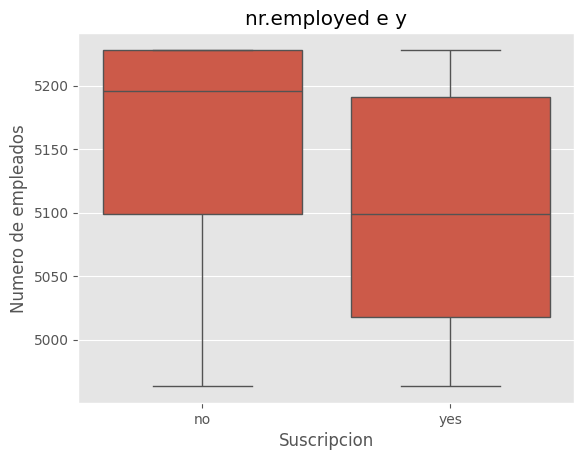

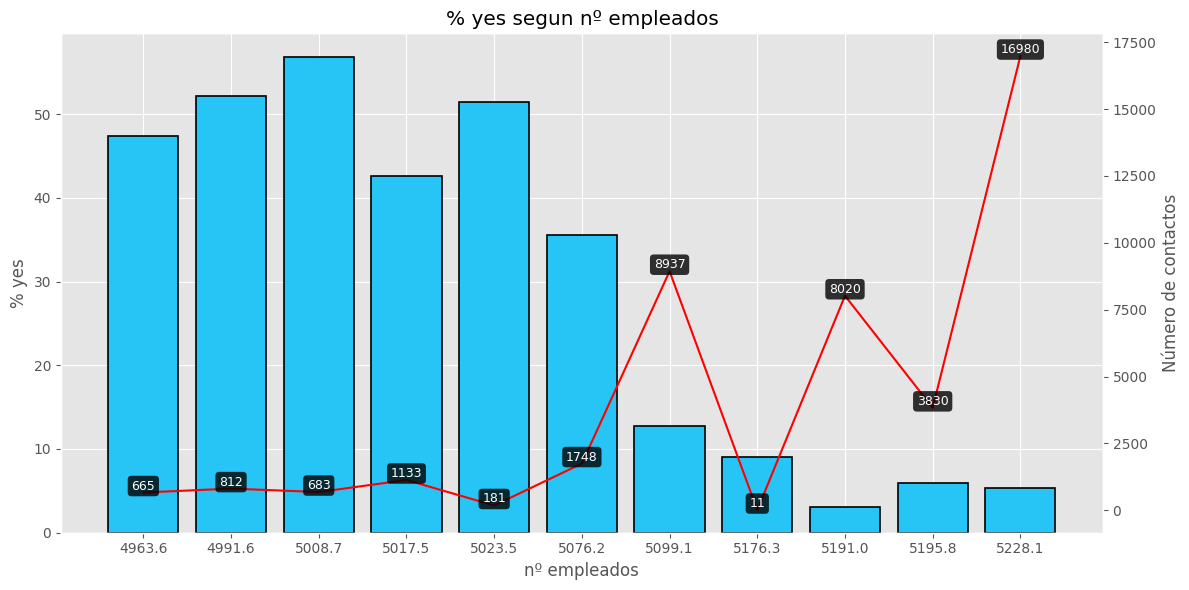

In [62]:
# 4.5 nr.employed (El número de empleados).

# Grafico 1: boxplot
sns.boxplot(data=df, x='y', y='nr.employed')
plt.title('nr.employed e y')
plt.xlabel('Suscripcion')
plt.ylabel('Numero de empleados')
plt.show()

# Conclusion 1: El boxplot muestra una diferencia clara entre las distribuciones de nr.employed para los clientes que suscriben el producto (yes) y los que no (no).
#  En el grupo yes, la distribución está desplazada hacia valores más bajos y presenta una mediana cercana a 5.100, 
# mientras que en el grupo no la mediana se sitúa alrededor de 5.200. 
# Esto sugiere que las suscripciones al depósito tienden a producirse en periodos en los que el número de empleados es menor,
#  es decir, en contextos económicos menos favorables.

# Grafico 2: Tablas de proporciones (yes)

# Proporciones
tabla = pd.crosstab(
    df['nr.employed'],
    df['y'],
    normalize='index'
).round(3) * 100

tabla = tabla.sort_index()

# Conteo
conteo = df['nr.employed'].value_counts().sort_index()

#  asegurar mismo orden exacto
conteo = conteo.reindex(tabla.index)

# Figura
fig, ax1 = plt.subplots(figsize=(12,6))

# 1º Gráfico (barras)
ax1.bar(tabla.index.astype(str), tabla['yes'], color='#27C5F5', edgecolor='black', linewidth=1.2)
ax1.set_title('% yes segun nº empleados')
ax1.set_ylabel('% yes')
ax1.set_xlabel('nº empleados')

# 2º Gráfico (línea)
ax2 = ax1.twinx()

ax2.plot(
    tabla.index.astype(str),
    conteo.values,
    color='red'
)

ax2.set_ylabel('Número de contactos')
ax2.grid(False)

# Etiquetas con fondo negro redondeado
for i, v in enumerate(conteo.values):
    ax2.text(
        i,
        v,
        str(v),
        ha='center',
        va='bottom',
        fontsize=9,
        color='white',  # texto blanco

        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="black",
            edgecolor="none",
            alpha=0.8
        )
    )

plt.tight_layout()
plt.show()

# Conclusion Final: El análisis muestra una asociación negativa entre el número de empleados (nr.employed) y la probabilidad de suscripción del producto. 
# En periodos con menor nivel de empleo (indicador de peor situación macroeconómica), la tasa de conversión tiende a ser mayor. 
# Aunque el número de contactos varía a lo largo de los distintos niveles de nr.employed, 
# no se observa de forma directa que este explique las diferencias en la tasa de suscripción.



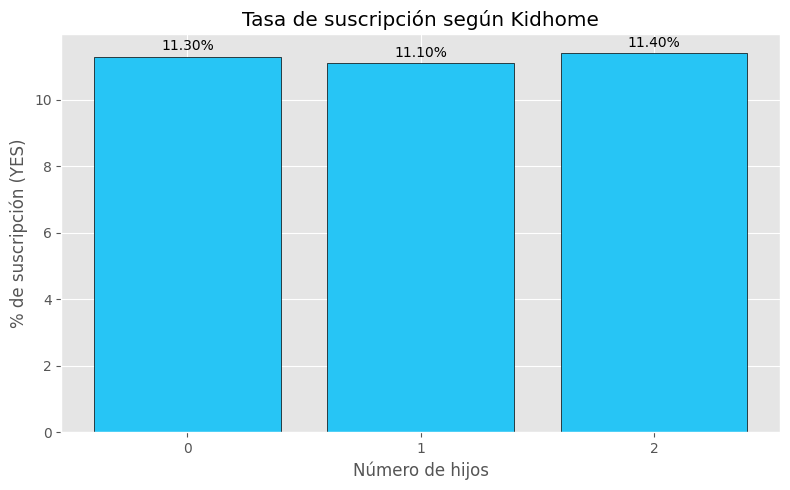

In [63]:
# 5. Familia
# 5.1 Kidhome (Indica el número de niños en el hogar del cliente)

# 1. Tabla de proporciones
tabla = pd.crosstab(
    df['Kidhome'],
    df['y'],
    normalize='index'
).round(3) * 100

tabla = tabla.sort_index()

# 2. Figura
fig, ax = plt.subplots(figsize=(8,5))

# 3. Barras (% yes)
ax.bar(
    tabla.index.astype(str),
    tabla['yes'],
    color='#27C5F5',
    edgecolor='black'
)

# 4. Etiquetas
ax.set_title('Tasa de suscripción según Kidhome')
ax.set_xlabel('Número de hijos')
ax.set_ylabel('% de suscripción (YES)')

# 5. Valores encima de las barras
for i, v in enumerate(tabla['yes']):
    ax.text(i, v + 0.2, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

# Conclusion: No se observan diferencias significativas en la tasa de suscripción según el número de niños en el hogar, ya que los valores se mantienen prácticamente constantes.


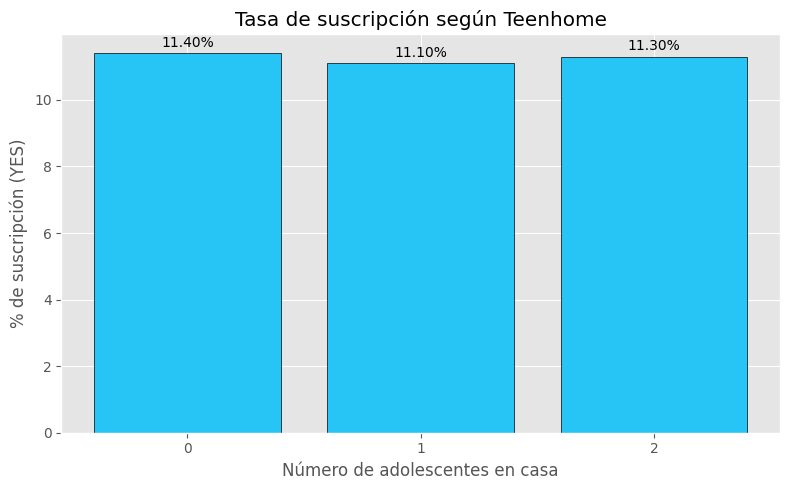

In [64]:
# 5.2 Teenhome (Indica el número de adolescentes en el hogar del cliente)
# 1. Tabla de proporciones
tabla = pd.crosstab(
    df['Teenhome'],
    df['y'],
    normalize='index'
).round(3) * 100

tabla = tabla.sort_index()

# 2. Figura
fig, ax = plt.subplots(figsize=(8,5))

# 3. Barras (% yes)
ax.bar(
    tabla.index.astype(str),
    tabla['yes'],
    color='#27C5F5',
    edgecolor='black'
)

# 4. Títulos y etiquetas
ax.set_title('Tasa de suscripción según Teenhome')
ax.set_xlabel('Número de adolescentes en casa')
ax.set_ylabel('% de suscripción (YES)')

# 5. Valores encima de las barras
for i, v in enumerate(tabla['yes']):
    ax.text(i, v + 0.2, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

# Conclusion: No se observan diferencias significativas en la tasa de suscripción según el número de adolescentes en el hogar, ya que los valores se mantienen prácticamente constantes.



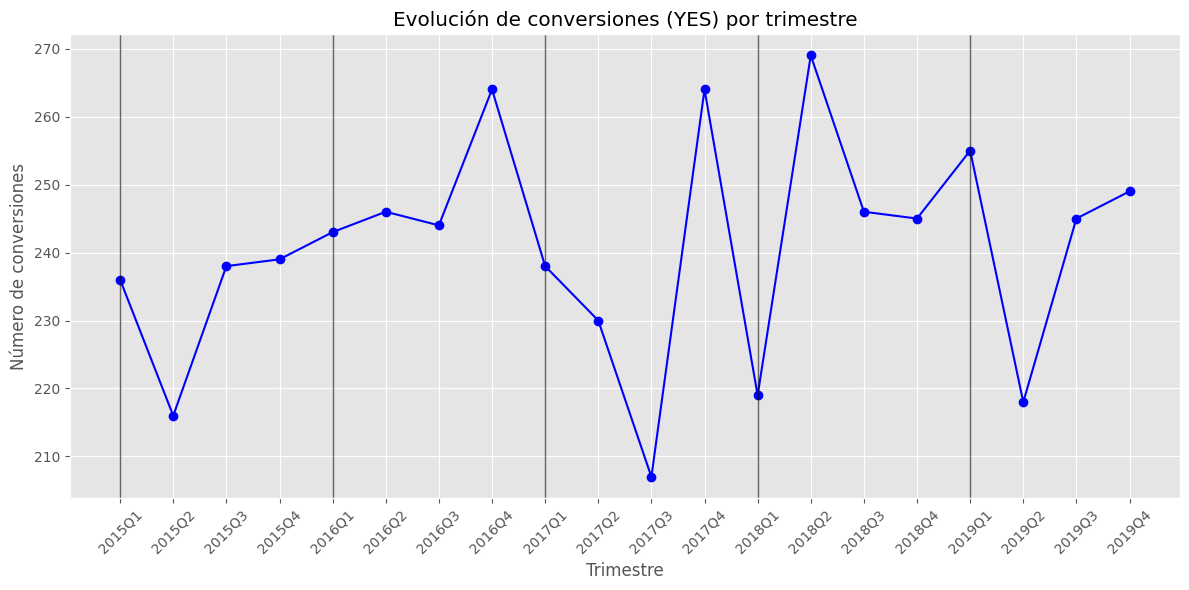

In [65]:
# 6. Tiempo
# Proporciones por fecha

# Trimestre
df['quarter'] = df['date'].dt.to_period('Q')
df['year'] = df['date'].dt.year

# Tabla YES
tabla_trim = pd.crosstab(
    df['quarter'],
    df['y']
).sort_index()

# Figura
fig, ax = plt.subplots(figsize=(12,6))

# Línea YES
ax.plot(
    tabla_trim.index.astype(str),
    tabla_trim['yes'],
    color='blue',
    marker='o'
)

# Líneas verticales por año
years = df['year'].sort_values().unique()

for i, q in enumerate(tabla_trim.index):
    # detectar inicio de año (Q1)
    if "Q1" in str(q):
        ax.axvline(i, color='black', linewidth=1, alpha=0.6)

ax.set_title('Evolución de conversiones (YES) por trimestre')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de conversiones')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Conclusiones: Se muestra un comportamiento cíclico con estacionalidad marcada,
#  donde los trimestres finales e iniciales rinden mejor. No hay crecimiento estructural evidente,
#  lo que podría indicar un mercado maduro o estancado que requeriría acciones específicas para romper el techo de ~270 conversiones.

In [66]:
# 7. Pasar el df a la carpeta processed como archivo csv

df.to_csv('../Data/processed/df_processed.csv', index = False)


In [67]:
# 8. Correlacion 
df_copia = df.copy()
df_copia["y"] = df_copia["y"].map({"no": 0, "yes": 1})

df_numeric = df_copia.select_dtypes(include=["int64", "float64"])
correlation_matrix = df_numeric.corr()
correlation_matrix

# Variables que MÁS influyen en Y por orden de mayor a menor:
# duration → 0.4048,
# euribor3m → -0.304
# nr.employed → -0.355
# emp.var.rate → -0.298
# cons.price.idx → -0.135 # Relacion débil pero negativa

# En contraste, variables como income, kidhome, teenhome o numwebvisitsmonth muestran correlaciones prácticamente nulas con y, 
# lo que sugiere una baja relación lineal con la respuesta del cliente. Adicionalmente, 
# se observa una alta correlación entre algunas variables macroeconómicas (por ejemplo, emp.var.rate y euribor3m), lo que indica posible multicolinealidad entre ellas.

,age,duration,campaign,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,Income,Kidhome,Teenhome,NumWebVisitsMonth,year
age,1.000000,0.000176,0.005517,-0.002584,-0.000607,0.120028,0.007733,-0.018021,0.029041,0.002089,0.000927,-0.001067,-0.003730,-0.000345
duration,0.000176,1.000000,-0.071956,-0.027158,0.005997,-0.007631,-0.032982,-0.044157,0.404818,-0.002761,-0.000759,-0.005937,0.000750,-0.002427
campaign,0.005517,-0.071956,1.000000,0.152084,0.128288,-0.012867,0.134916,0.145089,-0.066376,-0.003736,-0.006733,0.000802,0.004470,-0.005448
emp.var.rate,-0.002584,-0.027158,0.152084,1.000000,0.774857,0.192004,0.955403,0.907162,-0.298461,-0.008640,-0.004026,0.001431,-0.006914,0.003926
cons.price.idx,-0.000607,0.005997,0.128288,0.774857,1.000000,0.055367,0.675128,0.521675,-0.135434,-0.010621,0.001407,0.003948,-0.004939,0.008521
cons.conf.idx,0.120028,-0.007631,-0.012867,0.192004,0.055367,1.000000,0.271531,0.097433,0.057316,0.001571,-0.002109,0.000989,0.006740,-0.004044
euribor3m,0.007733,-0.032982,0.134916,0.955403,0.675128,0.271531,1.000000,0.929636,-0.304272,-0.007108,-0.006093,0.001515,-0.007138,0.001637
nr.employed,-0.018021,-0.044157,0.145089,0.907162,0.521675,0.097433,0.929636,1.000000,-0.355808,-0.003926,-0.007266,-0.000756,-0.010101,0.001007
y,0.029041,0.404818,-0.066376,-0.298461,-0.135434,0.057316,-0.304272,-0.355808,1.000000,-0.004635,0.000162,-0.000743,0.000561,0.002706
Income,0.002089,-0.002761,-0.003736,-0.008640,-0.010621,0.001571,-0.007108,-0.003926,-0.004635,1.000000,0.001350,0.006480,0.002500,-0.003671
